#Carga de librerías

In [2]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from datasets import Dataset, DatasetDict, load_from_disk
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
# En versiones recientes, TensorBoardCallback está en integrations
from transformers.integrations import TensorBoardCallback

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install pandas scikit-learn datasets sentence-transformers transformers torch scipy


In [4]:
%cd /content/drive/MyDrive/PLN-PROYECTO/Implementación


/content/drive/MyDrive/PLN-PROYECTO/Implementación


## Implementación Tarea 2

### Preparado de dataset

In [7]:
def prepare_t2_datasets(base_dir: str, train_size = None) -> DatasetDict:
    """
    Carga y procesa el dataset para la Tarea 2.
    - Reduce el train a 250,000 muestras.
    - Se queda solo con la etiqueta 'toxic' como continua para train,
      eliminando el resto de labels.
    - Junta el test con test_labels.csv.
    - Convierte a formato Dataset de HuggingFace.
    """
    data_dir = os.path.join(base_dir, "T2", "data")

    print("Cargando y procesando el conjunto de Train...")
    train_path = os.path.join(data_dir, "jigsaw-toxic-comment-train-processed-seqlen128.csv", "jigsaw-toxic-comment-train-processed-seqlen128.csv")
    df_train = pd.read_csv(train_path)

    # Reducir el tamaño de train a 250,000 muestras
    print(f"Reduciendo train de {len(df_train)} a {train_size} muestras...")
    if train_size is not None:
      df_train = df_train.sample(n=train_size, random_state=42)

    # Columnas que queremos conservar
    cols_to_keep = ['id', 'comment_text', 'toxic', 'input_word_ids', 'input_mask', 'all_segment_id']

    # Quedarnos solo con las columnas deseadas y asegurar que 'toxic' es continua (float)
    df_train = df_train[cols_to_keep].copy()
    df_train['toxic'] = df_train['toxic'].astype(float)

    print("Cargando y procesando el conjunto de Validación...")
    val_path = os.path.join(data_dir, "validation-processed-seqlen128.csv", "validation-processed-seqlen128.csv")
    df_val = pd.read_csv(val_path)
    # Seleccionar las mismas columnas
    cols_val = [c for c in cols_to_keep if c in df_val.columns]
    df_val = df_val[cols_val].copy()
    if 'toxic' in df_val.columns:
        df_val['toxic'] = df_val['toxic'].astype(float)

    print("Cargando y procesando el conjunto de Test...")
    test_path = os.path.join(data_dir, "test-processed-seqlen128.csv", "test-processed-seqlen128.csv")
    test_labels_path = os.path.join(data_dir, "test_labels.csv")

    df_test = pd.read_csv(test_path)
    df_test_labels = pd.read_csv(test_labels_path)

    # Juntar test con sus etiquetas
    print("Uniendo test con test_labels...")
    df_test = pd.merge(df_test, df_test_labels, on='id', how='inner')

    # Seleccionar columnas
    cols_test = [c for c in cols_to_keep if c in df_test.columns]
    df_test = df_test[cols_test].copy()
    if 'toxic' in df_test.columns:
        df_test['toxic'] = df_test['toxic'].astype(float)

    print("\nConvirtiendo a formato Dataset de HuggingFace...")
    train_dataset = Dataset.from_pandas(df_train, preserve_index=False)
    val_dataset = Dataset.from_pandas(df_val, preserve_index=False)
    test_dataset = Dataset.from_pandas(df_test, preserve_index=False)

    hf_datasets = DatasetDict({
        'train': train_dataset,
        'validation': val_dataset,
        'test': test_dataset
    })

    print("\n--- Resumen del Dataset ---")
    print(hf_datasets)

    return hf_datasets


In [6]:
# La ruta base es la carpeta actual de implementación
import os
base_dir = os.getcwd()

In [10]:


# Preparamos el dataset
hf_data = prepare_t2_datasets(base_dir)

# Guardamos en disco para que el uso posterior sea instantáneo
processed_dir = os.path.join(base_dir, "T2", "data", "hf_dataset_clean")
os.makedirs(processed_dir, exist_ok=True)
hf_data.save_to_disk(processed_dir)
print(f"\nDataset procesado y guardado en: {processed_dir}")

# Pequeña visualización del dataset para el usuario
print("\n--- Visualización de una muestra de Train ---")
sample = hf_data['train'][0]
for k, v in sample.items():
  if isinstance(v, list) and len(v) > 10:
    print(f"{k}: {v[:5]} ... {v[-5:]} (length: {len(v)})")
  elif isinstance(v, str) and len(v) > 100:
    print(f"{k}: {v[:100]}...")
  else:
    print(f"{k}: {v}")

Cargando y procesando el conjunto de Train...
Reduciendo train de 223549 a None muestras...
Cargando y procesando el conjunto de Validación...
Cargando y procesando el conjunto de Test...
Uniendo test con test_labels...

Convirtiendo a formato Dataset de HuggingFace...

--- Resumen del Dataset ---
DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'input_word_ids', 'input_mask', 'all_segment_id'],
        num_rows: 223549
    })
    validation: Dataset({
        features: ['id', 'comment_text', 'toxic', 'input_word_ids', 'input_mask', 'all_segment_id'],
        num_rows: 8000
    })
    test: Dataset({
        features: ['id', 'comment_text', 'toxic', 'input_word_ids', 'input_mask', 'all_segment_id'],
        num_rows: 63812
    })
})


Saving the dataset (0/1 shards):   0%|          | 0/223549 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/8000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/63812 [00:00<?, ? examples/s]


Dataset procesado y guardado en: /content/drive/MyDrive/PLN-PROYECTO/Implementación/T2/data/hf_dataset_clean

--- Visualización de una muestra de Train ---
id: 0000997932d777bf
comment_text: Explanation
Why the edits made under my username Hardcore Metallica Fan were reverted? They weren't ...
toxic: 0.0
input_word_ids: (101, 27746, 31609, 11809, 24781, 10105, 70971, 10107, 11019, 10571, 15127, 29115, 23920, 72832, 566...
input_mask: (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...
all_segment_id: (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...


### Preprocesado

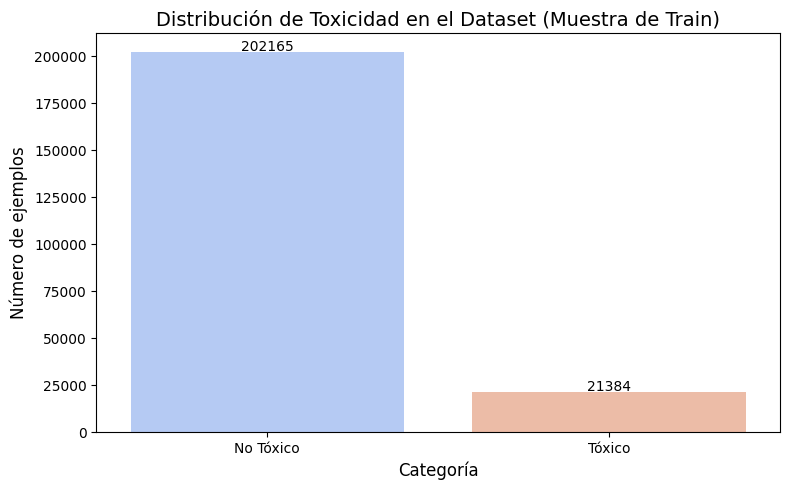


--- Ejemplos de comentarios No Tóxicos ---
  1. "What the freak happened to my previous entry???  Did someone delete it???  

Historical context behind Japanese occupation of Korea is crucial to unde..."
  2. "::Thanks!  However, I just found a problem: if a tag already exists, the script duplicates the †ag.  Is the any way to get around this?..."
  3. "wikibreak | back=whenever the community rids itself of double standards, adopts an instant-block policy towards those who call others out for clinical..."

--- Ejemplos de comentarios Tóxicos ---
  1. "YOU WANNA FUCKING GO YOU STUPID CUNT, I WILL FUCKING KILL YOU AND EAT YOUR FUCKING FLESH YOU CUNT, I WILL FUCKING SHOW YOU THAT THERE ARE FUCKING CUNT..."
  2. "== Semi-protected edit request on 30 April 2015 == 

  

  

    
 Parker is A FUCKING BUNNY KILLER!@!!!!!!!..."
  3. "== Hey, Sup == 

 Fuck you nigger..."


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

try:
    # Convertimos el dataset de HuggingFace a Pandas para visualización rápida
    df_viz = hf_data['train'].to_pandas()

    # Creamos una versión binaria para la visualización
    df_viz['is_toxic'] = df_viz['toxic'].apply(lambda x: 'Tóxico' if x >= 0.5 else 'No Tóxico')

    # Mostramos la distribución
    plt.figure(figsize=(8, 5))
    label_counts = df_viz['is_toxic'].value_counts().reset_index()
    label_counts.columns = ['Categoría', 'Cantidad']

    # Corregimos el uso de palette asignando hue para evitar el FutureWarning
    ax = sns.barplot(data=label_counts, x='Categoría', y='Cantidad', hue='Categoría', palette="coolwarm", legend=False)

    plt.title('Distribución de Toxicidad en el Dataset (Muestra de Train)', fontsize=14)
    plt.xlabel('Categoría', fontsize=12)
    plt.ylabel('Número de ejemplos', fontsize=12)

    for i, count in enumerate(label_counts['Cantidad']):
        ax.text(i, count + 500, str(count), ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    # Exploramos ejemplos reales
    print("\n--- Ejemplos de comentarios No Tóxicos ---")
    for i, text in enumerate(df_viz[df_viz['toxic'] < 0.5]['comment_text'].sample(3)):
        print(f"  {i+1}. \"{text[:150]}...\"")

    print("\n--- Ejemplos de comentarios Tóxicos ---")
    for i, text in enumerate(df_viz[df_viz['toxic'] >= 0.5]['comment_text'].sample(3)):
        print(f"  {i+1}. \"{text[:150]}...\"")

except Exception as e:
    print(f"Error al visualizar el dataset: {e}")

In [ ]:
# Verificamos la calidad de los datos adaptado a la Tarea 2
def verificar_calidad_datos(df):
    """
    Verifica la calidad de los datos, identificando problemas potenciales.

    Args:
        df: DataFrame con los datos (Jigsaw)

    Returns:
        Diccionario con estadísticas de calidad
    """
    # El texto en este dataset está en 'comment_text'
    col_texto = 'comment_text'

    # Verificamos valores nulos
    nulos = df.isnull().sum()

    # Verificamos duplicados
    duplicados = df.duplicated().sum()

    # Verificamos textos vacíos (manejando posibles nulos)
    textos_vacios = (df[col_texto].fillna('').str.strip() == '').sum()

    # Verificamos textos muy cortos (menos de 3 palabras)
    textos_cortos = (df[col_texto].fillna('').str.split().str.len() < 3).sum()

    # Calculamos estadísticas de longitud
    longitudes = df[col_texto].fillna('').str.split().str.len()
    stats_longitud = {
        'min': longitudes.min(),
        'max': longitudes.max(),
        'media': longitudes.mean(),
        'mediana': longitudes.median()
    }

    # Creamos resumen
    calidad = {
        'nulos': nulos.to_dict(),
        'duplicados': duplicados,
        'textos_vacios': textos_vacios,
        'textos_cortos': textos_cortos,
        'stats_longitud': stats_longitud
    }

    # Mostramos resultados
    print("Verificación de calidad de datos (Tarea 2):")
    print(f"- Valores nulos totales: {sum(nulos)}")
    if sum(nulos) > 0:
        print(f"  Detalle: {nulos[nulos > 0].to_dict()}")

    print(f"- Duplicados: {duplicados} ({duplicados/len(df):.2%} del total)")
    print(f"- Textos vacíos: {textos_vacios} ({textos_vacios/len(df):.2%} del total)")
    print(f"- Textos muy cortos (<3 palabras): {textos_cortos} ({textos_cortos/len(df):.2%} del total)")

    print("\nEstadísticas de longitud (palabras por texto):")
    print(f"- Mínimo: {stats_longitud['min']}")
    print(f"- Máximo: {stats_longitud['max']}")
    print(f"- Media: {stats_longitud['media']:.2f}")
    print(f"- Mediana: {stats_longitud['mediana']}")

    return calidad

# Ejecutamos la verificación sobre la muestra de visualización
calidad_t2 = verificar_calidad_datos(df_viz)

Verificación de calidad de datos (Tarea 2):
- Valores nulos totales: 0
- Duplicados: 0 (0.00% del total)
- Textos vacíos: 0 (0.00% del total)
- Textos muy cortos (<3 palabras): 481 (0.22% del total)

Estadísticas de longitud (palabras por texto):
- Mínimo: 1
- Máximo: 2321
- Media: 66.52
- Mediana: 35.0


In [ ]:
# Limpieza del dataset oficial (Hugging Face DatasetDict)
print(f"Tamaño original (train): {hf_data['train'].num_rows} filas")

# Filtramos para mantener solo filas con texto válido en todas las particiones
hf_data = hf_data.filter(lambda x: x['comment_text'] is not None and len(str(x['comment_text']).strip()) > 0)

print(f"Tamaño tras la limpieza (train): {hf_data['train'].num_rows} filas")
print("Limpieza completada en train, validation y test.")

Tamaño original (train): 223549 filas


Filter:   0%|          | 0/223549 [00:00<?, ? examples/s]

Filter:   0%|          | 0/8000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/63812 [00:00<?, ? examples/s]

Tamaño tras la limpieza (train): 223549 filas
Limpieza completada en train, validation y test.


In [ ]:
def prepare_labels(example):
        example['labels'] = int(round(float(example['toxic'])))
        return example

print("Preparando etiquetas (Hard Labels)...")
hf_data = hf_data.map(prepare_labels)

Preparando etiquetas (Hard Labels)...


Map:   0%|          | 0/223549 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/63812 [00:00<?, ? examples/s]

In [ ]:
print("Calculando pesos de clases para el desbalanceo...")
train_labels = hf_data['train']['labels']
num_ones = sum(train_labels)
num_zeros = len(train_labels) - num_ones
total = len(train_labels)

weight_0 = total / (2.0 * num_zeros) if num_zeros > 0 else 1.0
weight_1 = total / (2.0 * num_ones) if num_ones > 0 else 1.0
class_weights = torch.tensor([weight_0, weight_1], dtype=torch.float)
print(f"Pesos calculados -> Clase 0: {weight_0:.4f}, Clase 1: {weight_1:.4f}")


Calculando pesos de clases para el desbalanceo...
Pesos calculados -> Clase 0: 0.5529, Clase 1: 5.2270


Los dataset ya vienen tokenizados para introducirlos en BERT, no obstante nuestro modelo multilingue XLM-RoBERTa requiere otro tokenizador, veamos:

#### Tokenizador propio de XLM-RoBERTa

In [ ]:
from transformers import AutoTokenizer

# 2. Cargar Tokenizador de XLM-RoBERTa
model_name = "xlm-roberta-base"
# model_name="jhu-clsp/mmBERT-small"
print(f"Cargando tokenizador: {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 3. Función de Tokenización con limpieza de tipos
def tokenize_function(examples):
    # Forzamos que todos los elementos sean strings para evitar errores con NaNs
    texts = [str(text) if text is not None else "" for text in examples['comment_text']]
    return tokenizer(texts, padding="max_length", truncation=True, max_length=128)

print("Tokenizando los textos...")
# Removemos las columnas originales de texto e IDs, pero mantenemos 'labels' que creamos para el entrenamiento
columns_to_remove = ['id', 'comment_text', 'toxic', 'input_word_ids', 'input_mask', 'all_segment_id']

# Procesamos el dataset
tokenized_datasets = hf_data.map(tokenize_function, batched=True, remove_columns=columns_to_remove)
tokenized_datasets.set_format("torch")

print("Tokenización completada exitosamente. Columnas disponibles:", tokenized_datasets['train'].column_names)

Cargando tokenizador: xlm-roberta-base...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

Tokenizando los textos...


Map:   0%|          | 0/223549 [00:00<?, ? examples/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/63812 [00:00<?, ? examples/s]

Tokenización completada exitosamente. Columnas disponibles: ['labels', 'input_ids', 'attention_mask']


### Modelo

In [ ]:
print(f"Instanciando {model_name} con num_labels=1 para Soft-Labeling...")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Instanciando xlm-roberta-base con num_labels=1 para Soft-Labeling...


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(eval_pred):
    """
    Calcula métricas clave para clasificación binaria.
    """
    predictions, labels = eval_pred

    # El modelo escupe 'logits' de forma (N, 2).
    # Tomamos el argmax para obtener la clase predicha.
    preds_bin = np.argmax(predictions, axis=1)

    # Aseguramos que labels sean enteros
    labels_bin = labels.astype(int)

    return {
        "accuracy": accuracy_score(labels_bin, preds_bin),
        "f1": f1_score(labels_bin, preds_bin, zero_division=0),
        "precision": precision_score(labels_bin, preds_bin, zero_division=0),
        "recall": recall_score(labels_bin, preds_bin, zero_division=0)
    }

class ImbalancedTrainer(Trainer):
    """
    Sobrescribimos el Trainer clásico para inyectar explícitamente nuestra pérdida
    con CrossEntropyLoss y pesos, lidiando así con el desbalanceo de clases.
    """
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Obtenemos los pesos de la clase que inyectamos antes de entrenar
        if hasattr(self, "class_weights") and self.class_weights is not None:
            weight = self.class_weights.to(logits.device)
            loss_fct = nn.CrossEntropyLoss(weight=weight)
        else:
            loss_fct = nn.CrossEntropyLoss()

        # labels deben ser long para CrossEntropyLoss
        loss = loss_fct(logits, labels.long())

        return (loss, outputs) if return_outputs else loss


In [ ]:
output_dir = os.path.join(base_dir, "models", "T2_xlm-roberta_toxic_solo_densas")
logging_dir = os.path.join(output_dir, "logs")

In [ ]:
# 1. Congelar los embeddings
for param in model.roberta.embeddings.parameters():
    param.requires_grad = False

# 2. Congelar las 9 primeras capas del encoder (0 a 8)
for i in range(12):
    for param in model.roberta.encoder.layer[i].parameters():
        param.requires_grad = False

# # 3. Asegurar que las últimas capas (9, 10 y 11) SÍ se entrenen
# for i in range(9, 12):
#     for param in model.roberta.encoder.layer[i].parameters():
#         param.requires_grad = True

# 4. Asegurar que la cabeza clasificadora se entrene
# El pooler puede ser None en XLM-RoBERTa, lo manejamos con un condicional
if hasattr(model.roberta, 'pooler') and model.roberta.pooler is not None:
    for param in model.roberta.pooler.parameters():
        param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

# Calcular y mostrar el número de parámetros entrenables
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros entrenables: {trainable_params:,}")
print(f"Parámetros totales: {total_params:,}")
print(f"Porcentaje entrenable: {100 * trainable_params / total_params:.2f}%")

Parámetros entrenables: 592,130
Parámetros totales: 278,045,186
Porcentaje entrenable: 0.21%


In [ ]:
import sys
import torchvision.io

# Fix for the torchvision VideoReader ImportError in datasets
try:
    from torchvision.io import VideoReader
except ImportError:
    class MockVideoReader: pass
    torchvision.io.VideoReader = MockVideoReader

training_args = TrainingArguments(
    output_dir=output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=256,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    lr_scheduler_type="cosine_with_restarts",
    warmup_ratio=0.1,
    logging_dir=logging_dir,
    logging_steps=50,
    report_to=["tensorboard"],
    fp16=torch.cuda.is_available(),
)

callbacks = [
    EarlyStoppingCallback(early_stopping_patience=2),
]

# 6. Entrenador Personalizado (ImbalancedTrainer)
trainer = ImbalancedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    callbacks=callbacks
)
trainer.class_weights = class_weights

print("\n" + "="*50)
print("¡Comenzando el Entrenamiento! ")
print("Puedes seguir el progreso abriendo otra terminal y ejecutando:")
print(f"tensorboard --logdir={logging_dir}")
print("="*50 + "\n")

trainer.train()

# 7. Evaluación y Guardado
print("\nEvaluando el modelo con el conjunto de Test...")
test_results = trainer.evaluate(tokenized_datasets["test"], metric_key_prefix="test")

print("\nResultados en Test:")
for key, value in test_results.items():
    print(f"  {key}: {value:.4f}")

final_model_path = os.path.join(output_dir, "final_model")
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)
print(f"\n¡Entrenamiento completado exitosamente! El modelo final está en: {final_model_path}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



¡Comenzando el Entrenamiento! 
Puedes seguir el progreso abriendo otra terminal y ejecutando:
tensorboard --logdir=/content/drive/MyDrive/PLN-PROYECTO/Implementación/models/T2_xlm-roberta_toxic_solo_densas/logs



Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.578026,0.627992,0.791000,0.535297,0.406672,0.782927
2,0.489631,0.565298,0.846375,0.583813,0.500290,0.700813
3,0.450134,0.527275,0.835750,0.580460,0.477918,0.739024
4,0.428477,0.525786,0.853625,0.593262,0.517890,0.694309
5,0.436966,0.522262,0.849875,0.589682,0.508544,0.701626


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...


Evaluando el modelo con el conjunto de Test...


early stopping required metric_for_best_model, but did not find eval_f1 so early stopping is disabled



Resultados en Test:
  test_loss: 0.5466
  test_accuracy: 0.8130
  test_f1: 0.6262
  test_precision: 0.5707
  test_recall: 0.6937
  test_runtime: 124.2523
  test_samples_per_second: 513.5680
  test_steps_per_second: 16.0560
  epoch: 5.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


¡Entrenamiento completado exitosamente! El modelo final está en: /content/drive/MyDrive/PLN-PROYECTO/Implementación/models/T2_xlm-roberta_toxic_solo_densas/final_model


--- Generando predicciones detalladas en el conjunto de test ---


ya
Procesando metadatos de idiomas...

--- MÉTRICAS GLOBALES (Columna 'lang' no encontrada) ---
              precision    recall  f1-score   support

           0       0.90      0.85      0.88     49402
           1       0.57      0.69      0.63     14410

    accuracy                           0.81     63812
   macro avg       0.74      0.77      0.75     63812
weighted avg       0.83      0.81      0.82     63812



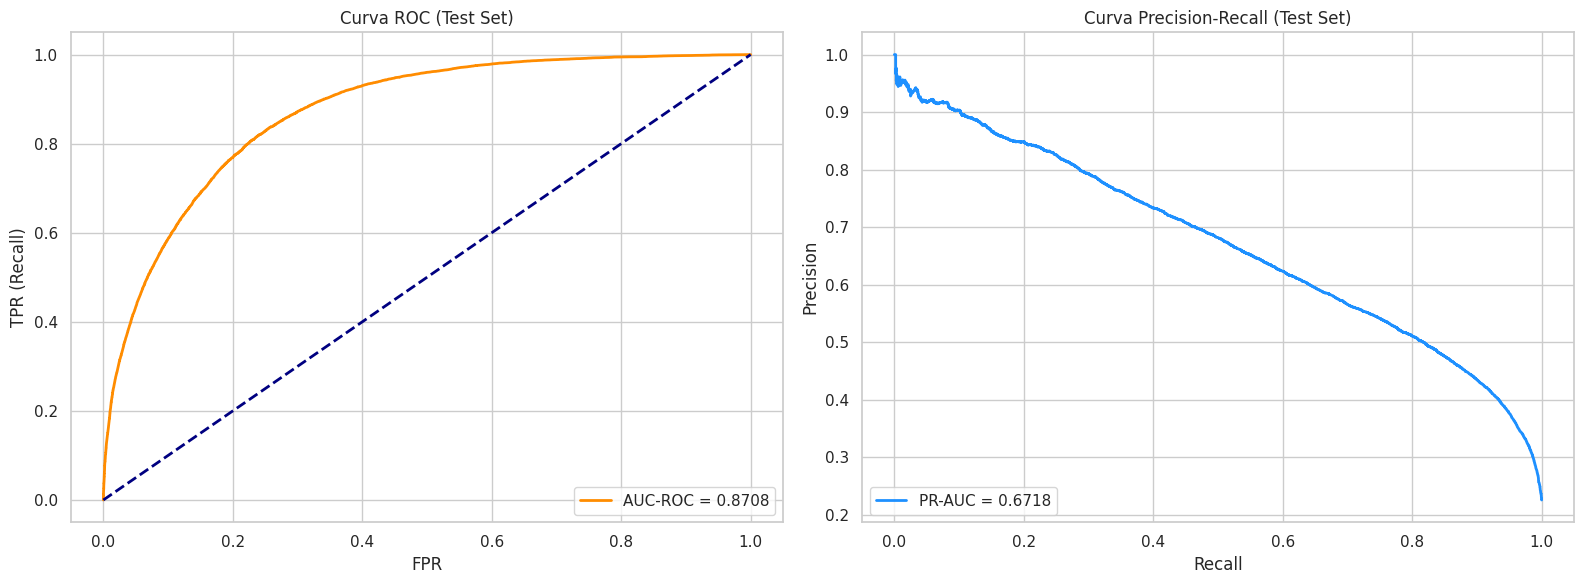

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, classification_report
import torch.nn.functional as F
import torch
import os

# 1. Obtener predicciones completas (Necesario para tener los logits y etiquetas)
print("--- Generando predicciones detalladas en el conjunto de test ---")
# Usamos trainer.predict en lugar de test_results porque test_results es solo un diccionario de métricas
predictions_output = trainer.predict(tokenized_datasets["test"])
print("ya")

logits = torch.from_numpy(predictions_output.predictions)
probs = F.softmax(logits, dim=-1).numpy()[:, 1]
preds_bin = np.argmax(predictions_output.predictions, axis=1)
true_labels = predictions_output.label_ids

# 2. Cargar metadatos de idioma y alinear con las etiquetas válidas
print("Procesando metadatos de idiomas...")
test_path = os.path.join(base_dir, "T2", "data", "test-processed-seqlen128.csv", "test-processed-seqlen128.csv")
test_labels_path = os.path.join(base_dir, "T2", "data", "test_labels.csv")

df_test_raw = pd.read_csv(test_path)
df_test_labels = pd.read_csv(test_labels_path)
df_full = pd.merge(df_test_raw, df_test_labels, on='id')

# Filtramos etiquetas -1 (no evaluadas) para que coincida con lo procesado por el Trainer
df_eval = df_full[df_full['toxic'] != -1].copy().reset_index(drop=True)
df_eval['pred'] = preds_bin

# 3. Mostrar métricas por idioma en formato tabla
if 'lang' in df_eval.columns:
    print("\n--- MÉTRICAS POR IDIOMA ---")
    summary_data = []
    for lang, group in df_eval.groupby('lang'):
        report = classification_report(group['toxic'], group['pred'], output_dict=True, zero_division=0)
        tk = '1.0' if '1.0' in report else '1'
        summary_data.append({
            'Idioma': lang.upper(),
            'Muestras': len(group),
            'F1-Score (Tóxicos)': f"{report[tk]['f1-score']:.2%}",
            'Precisión': f"{report[tk]['precision']:.2%}",
            'Recall': f"{report[tk]['recall']:.2%}",
            'Exactitud (Acc)': f"{report['accuracy']:.2%}"
        })
    display(pd.DataFrame(summary_data).sort_values('F1-Score (Tóxicos)', ascending=False))
else:
    print("\n--- MÉTRICAS GLOBALES (Columna 'lang' no encontrada) ---")
    print(classification_report(true_labels, preds_bin))

# 4. Graficar Curvas de Rendimiento
sns.set(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(true_labels, probs)
roc_auc_val = auc(fpr, tpr)
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC-ROC = {roc_auc_val:.4f}')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_title('Curva ROC (Test Set)')
ax1.set_xlabel('FPR')
ax1.set_ylabel('TPR (Recall)')
ax1.legend(loc="lower right")

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(true_labels, probs)
pr_auc_val = average_precision_score(true_labels, probs)
ax2.plot(recall, precision, color='dodgerblue', lw=2, label=f'PR-AUC = {pr_auc_val:.4f}')
ax2.set_title('Curva Precision-Recall (Test Set)')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

Cargando modelo y tokenizador desde: /content/drive/MyDrive/PLN-PROYECTO/Implementación/models/T2_xlm-roberta_toxic_solo_densas/final_model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Procesando 63812 muestras del nuevo archivo de test...


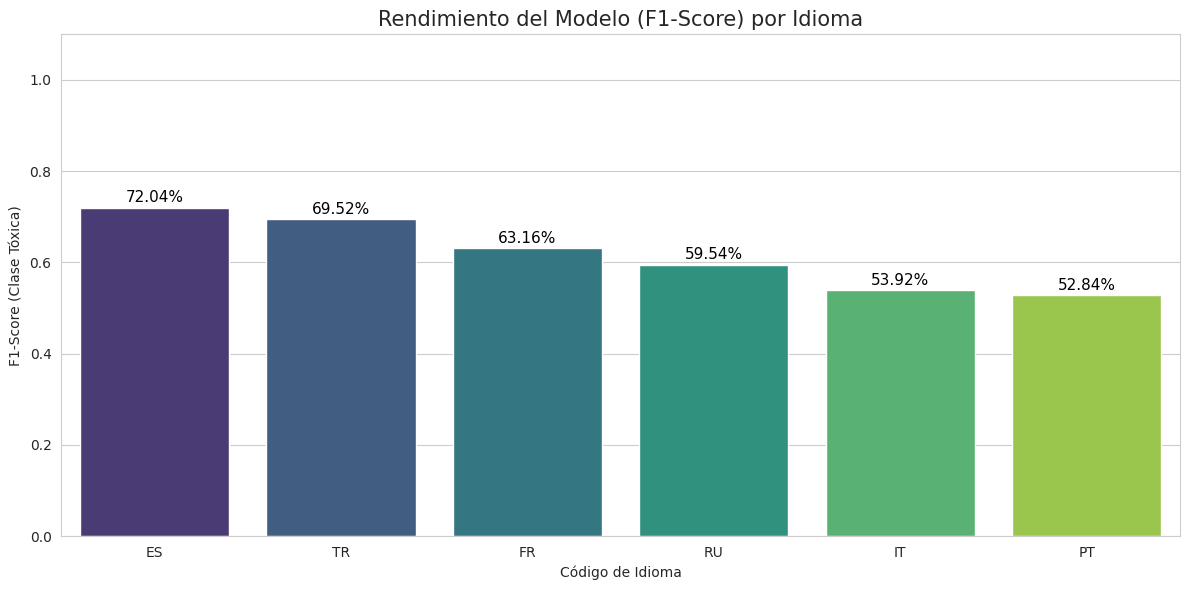

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import torch
import torch.nn.functional as F
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# 1. Cargar el nuevo archivo de test que contiene la columna 'lang'
new_test_path = os.path.join(base_dir, "T2", "data", "test.csv")
test_labels_path = os.path.join(base_dir, "T2", "data", "test_labels.csv")

df_test_new = pd.read_csv(new_test_path)
df_labels = pd.read_csv(test_labels_path)

# Unir con las etiquetas y filtrar las no evaluadas (-1)
df_merged = pd.merge(df_test_new, df_labels, on='id')
df_eval = df_merged[df_merged['toxic'] != -1].copy().reset_index(drop=True)

# 2. Cargar el modelo y el tokenizador guardados desde Drive
model_path = os.path.join(base_dir, "models", "T2_xlm-roberta_toxic_solo_densas", "final_model")
print(f"Cargando modelo y tokenizador desde: {model_path}...")

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 3. Tokenizar y predecir sobre este nuevo conjunto
print(f"Procesando {len(df_eval)} muestras del nuevo archivo de test...")
def quick_tokenize(texts):
    return tokenizer(list(texts), padding="max_length", truncation=True, max_length=128, return_tensors="pt")

all_preds = []
model.eval()
with torch.no_grad():
    for i in range(0, len(df_eval), 64):
        batch_texts = df_eval['content'].iloc[i:i+64].astype(str).tolist()
        inputs = quick_tokenize(batch_texts).to(device)
        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)

df_eval['pred'] = all_preds

# 4. Calcular métricas por idioma
lang_metrics = []
for lang, group in df_eval.groupby('lang'):
    report = classification_report(group['toxic'], group['pred'], output_dict=True, zero_division=0)
    label_key = '1.0' if '1.0' in report else '1' if '1' in report else None
    if label_key:
        f1 = report[label_key]['f1-score']
        lang_metrics.append({'Idioma': lang.upper(), 'F1-Score': f1})

df_plot = pd.DataFrame(lang_metrics).sort_values(by='F1-Score', ascending=False)

# 5. Graficar
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_plot, x='Idioma', y='F1-Score', palette="viridis", hue='Idioma', legend=False)

plt.title('Rendimiento del Modelo (F1-Score) por Idioma', fontsize=15)
plt.ylim(0, 1.1)
plt.ylabel('F1-Score (Clase Tóxica)')
plt.xlabel('Código de Idioma')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 7),
                textcoords='offset points')

plt.tight_layout()
plt.show()

In [8]:
import torch
import torch.nn.functional as F

# 1. Preparar subconjunto de español
df_es = df_eval[df_eval['lang'] == 'es'].copy()

# 2. Obtener probabilidades (Softmax) para el subconjunto español
print(f"Auditoría de fallos para Español ({len(df_es)} ejemplos)...")

def get_probs(texts):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for i in range(0, len(texts), 32):
            batch = texts[i:i+32].astype(str).tolist()
            inputs = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
            logits = model(**inputs).logits
            probs = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
    return all_probs

df_es['prob_toxic'] = get_probs(df_es['content'])

# 3. Categorización
# Tóxico con mucha probabilidad (> 0.9)
high_conf_toxic = df_es[df_es['prob_toxic'] > 0.9].sort_values('prob_toxic', ascending=False).head(3)

# Tóxico con poca probabilidad (cerca del umbral 0.5, e.g., 0.5 a 0.6)
low_conf_toxic = df_es[(df_es['prob_toxic'] >= 0.5) & (df_es['prob_toxic'] < 0.6)].head(3)

# No tóxico con mucha probabilidad (< 0.1)
high_conf_non_toxic = df_es[df_es['prob_toxic'] < 0.1].sort_values('prob_toxic').head(3)

def print_audit(title, df):
    print(f"\n--- {title} ---")
    if df.empty:
        print("No se encontraron ejemplos en esta categoría.")
    for i, row in df.iterrows():
        print(f"ID: {row['id']} | Prob: {row['prob_toxic']:.4f} | Real: {row['toxic']}")
        print(f"Texto: {str(row['content'])[:200]}...\n")

print_audit("EJEMPLOS: CLASIFICADO TÓXICO CON MUCHA PROBABILIDAD", high_conf_toxic)
print_audit("EJEMPLOS: CLASIFICADO TÓXICO CON POCA PROBABILIDAD (DUDAS)", low_conf_toxic)
print_audit("EJEMPLOS: CLASIFICADO NO TÓXICO CON MUCHA PROBABILIDAD", high_conf_non_toxic)

Auditoría de fallos para Español (8438 ejemplos)...

--- EJEMPLOS: CLASIFICADO TÓXICO CON MUCHA PROBABILIDAD ---
ID: 9978 | Prob: 0.9721 | Real: 1
Texto: asquerosa de mierda gemma so puton asquerosa . fascista de mnierda cuando te moriras puta. bailare sobre tu puta tumba zorrra....

ID: 21988 | Prob: 0.9501 | Real: 1
Texto: Cabron, hijo de puta, te voy a matar, me voy a cagar en tus muertos, me voy a follar a tu puta madre, te voy a rajar de arriba a abajo, hijo puta. Vas a independizar a tu puta madre....

ID: 14080 | Prob: 0.9261 | Real: 1
Texto: Que es esto?! Por dios, que es esto!! Bibliofilia y sexo explícito! Y la pobre Bárbara con cara de  Mucho hombre junto en actitud ambigua. Yo aquí sobro . Que vergüenza, te hacía hombre serio! PPPP ...


--- EJEMPLOS: CLASIFICADO TÓXICO CON POCA PROBABILIDAD (DUDAS) ---
ID: 7 | Prob: 0.5845 | Real: 0
Texto: el skate es unos de los deportes favoritos de la tierra con el skate puedes hacer truco como el flip flip 180 flip 360 flip backside et

# Evaluación de tarea

Vamos a simular una situación real de nuestra  plataforma de e-learning. Un profesor abrió una discusión en el foro de la plataforma con una pregunta evaluable para que los alumnos escribieran su respuesta y además pudieran discutir en el foro acerca de sus dudas en las respuestas. El objetivo del modelo T2 será detectar entre un conjunto de respuestas aquellas que muestren contenido ofensivo.

In [9]:
import torch
import torch.nn.functional as F

# 1. Definir respuestas con toxicidad más sutil (menos palabras 'tabú')
respuestas = [
    "La fotosíntesis es fundamental porque permite a las plantas producir su propio alimento usando la luz del sol.",
    "Las mitocondrias son orgánulos celulares encargados de suministrar la energía necesaria.",
    "Quizás si dejaras de decir tonterías en el foro y te pusieras a estudiar, entenderías algo de lo que estamos hablando.",
    "El ADN contiene las instrucciones genéticas usadas en el desarrollo de los organismos.",
    "Es increíble cómo pierden el tiempo explicando cosas tan básicas como si fuéramos niños pequeños. Qué nivel tan bajo."
]

# 2. Configuración del modelo para inferencia
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# 3. Evaluar cada respuesta
resultados = []

with torch.no_grad():
    for texto in respuestas:
        inputs = tokenizer(texto, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        logits = model(**inputs).logits
        probs = F.softmax(logits, dim=-1)
        prob_toxic = probs[0][1].item()
        es_toxic = "SÍ" if prob_toxic >= 0.5 else "NO"

        resultados.append({
            "Respuesta del alumno": texto,
            "Prob. Toxicidad": f"{prob_toxic:.4f}",
            "Marcado como Tóxico": es_toxic
        })

# 4. Mostrar resultados
df_resultados = pd.DataFrame(resultados)
print("--- EVALUACIÓN DE RESPUESTAS SUTILES ---")
display(df_resultados)

--- EVALUACIÓN DE RESPUESTAS SUTILES ---


,Respuesta del alumno,Prob. Toxicidad,Marcado como Tóxico
0,La fotosíntesis es fundamental porque permite ...,0.3480,NO
1,Las mitocondrias son orgánulos celulares encar...,0.3952,NO
2,Quizás si dejaras de decir tonterías en el for...,0.3719,NO
3,El ADN contiene las instrucciones genéticas us...,0.3431,NO
4,Es increíble cómo pierden el tiempo explicando...,0.6159,SÍ
